<a href="https://colab.research.google.com/github/Alilson2/Projeto_IA/blob/main/Copy_of_ProjetoIA_ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import xarray as xr # Ler arquivos netcdf
from google.colab import drive
import seaborn as sns

import matplotlib.patches as mpatches # Desenhar geometria em um mapa

In [ ]:
import os
import xarray as xr

# --- Clonar repositório se não existir ---
if not os.path.exists("Projeto_IA"):
    !git clone https://github.com/Alilson2/Projeto_IA.git
else:
    print("📁 Repositório 'Projeto_IA' já existe — pulando o clone.")

# --- Verificar se a pasta foi criada ---
if not os.path.exists("Projeto_IA"):
    raise FileNotFoundError("❌ A pasta 'Projeto_IA' não foi encontrada. O clone pode ter falhado.")
else:
    print("\n✅ Repositório clonado com sucesso!\n")
    print("Arquivos dentro da pasta Projeto_IA:\n", os.listdir("Projeto_IA"))

# --- Localizar arquivos .nc ---
arquivos_nc = [f for f in os.listdir("Projeto_IA") if f.endswith(".nc")]
if not arquivos_nc:
    raise FileNotFoundError("❌ Nenhum arquivo .nc encontrado na pasta Projeto_IA!")
else:
    print("\n📂 Arquivo(s) NetCDF encontrado(s):")
    for f in arquivos_nc:
        print(" -", f)

# --- Montar lista de caminhos ---
ARQUIVO = [os.path.join("Projeto_IA", f) for f in arquivos_nc]

# --- Função para corrigir longitude ---
def corrigir_longitude(ds):
    for coord in ["longitude", "lon"]:
        if coord in ds.coords:
            ds = ds.assign_coords({coord: ((ds[coord] + 180) % 360) - 180})
            ds = ds.sortby(coord)
    return ds

# --- Abrir arquivos com segurança (nova sintaxe) ---
try:
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='by_coords',
        parallel=True,           # usa múltiplos núcleos
        preprocess=corrigir_longitude,
        combine_attrs='override' # 🟢 substitui o antigo compat='override'
    )
except ValueError as e:
    print("\n⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...")
    dados = xr.open_mfdataset(
        ARQUIVO,
        combine='nested',
        concat_dim='valid_time',  # ajuste se sua dimensão temporal tiver outro nome
        parallel=True,
        preprocess=corrigir_longitude,
        combine_attrs='override'
    )

print("\n✅ Dataset carregado com sucesso!\n")
dados

Cloning into 'Projeto_IA'...
remote: Enumerating objects: 245, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 245 (delta 37), reused 24 (delta 24), pack-reused 205 (from 1)
Receiving objects: 100% (245/245), 163.62 MiB | 18.45 MiB/s, done.
Resolving deltas: 100% (61/61), done.

✅ Repositório clonado com sucesso!

Arquivos dentro da pasta Projeto_IA:
 ['(NOVEMBRO 2021-16 a 30).nc', '(JULHO 2023 - 1a15) 6fdadb7142db0ca316d72f4c3cf60eec.nc', 'MAR 2022 - 1a31.nc', '(JUNHO 2023 - 1a15) a6b209ca9f73a07c7a9f05f4683b0ce0.nc', '(JANEIRO 2023 - 16a31) 94ce3bca85fad1ca87acdd2bfbff170b.nc', '(JAN 2020-16 a 31).nc', '(OUTUBRO 2023 - 16a31).nc', 'DEZ 2022 - 16a31.nc', 'NOV 2022 - 16a30.nc', 'DEZ 2022 - 1a15.nc', 'Cópia_de_ProjetoIA_ver_David.ipynb', '(OUTUBRO 2024 - 1a15) c32ddd8a51679c9adea94613420cc6d5.nc', '(JUL 2020-25 a 31).nc', '(JULHO 2024 - 16a31) bbaf0148256b34f39eea38f68c677b6e.nc', 'AGO 2022 - 1a15.nc', '(FEVEREIRO 2023 -

/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'valid_time' ('valid_time',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:39: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



⚠️ Erro na combinação — tentando modo 'nested' (concat por tempo)...


/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'latitude' ('latitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(
/tmp/ipython-input-2195183609.py:48: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'longitude' ('longitude',) The recommendation is to set join explicitly for this case.
  dados = xr.open_mfdataset(



✅ Dataset carregado com sucesso!



<xarray.Dataset> Size: 464MB
Dimensions:     (valid_time: 43848, latitude: 12, longitude: 22)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 351kB 2021-11-16 ... 2020-05-24T2...
  * latitude    (latitude) float64 96B -24.2 -24.2 -24.1 ... -23.4 -23.3 -23.2
  * longitude   (longitude) float64 176B -47.2 -47.19 -47.1 ... -46.2 -46.19
    number      int64 8B 0
    expver      (valid_time) <U4 702kB dask.array<chunksize=(360,), meta=np.ndarray>
Data variables:
    d2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    t2m         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    slhf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    sshf        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    ssrd        (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    e           (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    u10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    v10         (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    sp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
    tp          (valid_time, latitude, longitude) float32 46MB dask.array<chunksize=(360, 11, 11), meta=np.ndarray>
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-10-26T20:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [ ]:
df = dados.to_dataframe()
df = df.dropna()

# --- 2️⃣ Verificar se há a coordenada temporal ---
if "valid_time" not in dados.coords:
    raise ValueError("❌ O dataset não contém uma coordenada temporal chamada 'valid_time'.")

# --- 3️⃣ Converter o eixo temporal para pandas.DatetimeIndex ---
tempo = pd.to_datetime(dados["valid_time"].values)

# --- 4️⃣ Criar DataFrame com componentes temporais ---
df_tempo = pd.DataFrame({
    "timestamp": tempo,
    "timestamp_segundos": tempo.view("int64"),   # segundos desde 1970
    "ano": tempo.year,
    "mes": tempo.month,
    "dia": tempo.day,
    "hora": tempo.hour,
    "minuto": tempo.minute,
    "segundo": tempo.second,
    "dia_semana": tempo.dayofweek,
    "dia_do_ano": tempo.dayofyear
})

#print(df_tempo.head())

# Exemplo: seleciona uma variável e um período
# Sort the dataset by valid_time before slicing
dados_sorted = dados.sortby('valid_time')
dados_filtrado = dados_sorted

# Converte para pandas sem estourar RAM
df_panda = dados_filtrado.to_dataframe().reset_index()
df_panda = df_panda.dropna()

# Junta com df_tempo
df_final = pd.merge(
    df_panda,
    df_tempo,
    left_on='valid_time',
    right_on='timestamp',
    how='left'
)



In [ ]:
import numpy as np
import pandas as pd
df_panda = df_final
def calcula_vapor_umidade(data):
    # Temperatura e ponto de orvalho em Celsius
    t2m_celsius = data["t2m"] - 273.15
    d2m_celsius = data["d2m"] - 273.15

    # 1) Pressão de vapor de saturação (es) em Pa
    es = 610.94 * np.exp(17.625 * t2m_celsius / (243.04 + t2m_celsius))

    # 2) Pressão de vapor real (ev) em Pa
    ev = 610.94 * np.exp(17.625 * d2m_celsius / (243.04 + d2m_celsius))

    # 3) Umidade Relativa (%)
    RH = 100 * ev / es

    # 4) Déficit de Pressão de Vapor (kPa)
    VPD = (es - ev) / 1000

    # Retorna como DataFrame para fácil concatenação
    return pd.DataFrame({
        "es": es,
        "ev": ev,
        "RH": RH,
        "VPD": VPD
    })

# --- Aplicar ao DataFrame original ---
resultados = calcula_vapor_umidade(df_panda)

# Adiciona novas colunas ao df_panda
df_panda = pd.concat([df_panda.reset_index(drop=True), resultados.reset_index(drop=True)], axis=1)

'''O_lim = -46.84
L_lim = -46.36
N_lim = -23.36
S_lim = -24

ind = np.where((df_panda['latitude'] >= S_lim) & (df_panda['latitude'] <= N_lim) & (df_panda['longitude'] <= L_lim) & (df_panda['longitude'] >= O_lim))[0]
df_panda = df_panda.iloc[ind].reset_index()'''

"O_lim = -46.84\nL_lim = -46.36\nN_lim = -23.36\nS_lim = -24\n\nind = np.where((df_panda['latitude'] >= S_lim) & (df_panda['latitude'] <= N_lim) & (df_panda['longitude'] <= L_lim) & (df_panda['longitude'] >= O_lim))[0]\ndf_panda = df_panda.iloc[ind].reset_index()"

In [ ]:
#RODE APENAS SE NÃO TIVER OS DADOS PRONTOS
from tqdm import tqdm
import numpy as np
import pandas as pd


def criar_dados(df_panda):

    variaveis = ['d2m', 't2m', 'u10', 'v10', 'slhf', 'sshf', 'ssrd',
                 'sp', 'e', 'tp', 'es', 'ev', 'RH', 'VPD']

    # Se quiser somar algumas variáveis, liste-as aqui
    vars_sum = []   # ex: ['e', 'tp']

    # Estatísticas a aplicar nas variáveis normais
    estatisticas = {
        "mean": "mean",
        "min": "min",
        "max": "max",
        "std": "std",
        "median": "median"
    }

    grouped = df_panda.groupby("valid_time")

    resultados = {}

    for var in variaveis:
        if var not in vars_sum:
            for label, func in estatisticas.items():
                resultados[f"{var}_{label}"] = grouped[var].agg(func)

        else:
            # Apenas SUM para variáveis definidas em vars_sum
            resultados[f"{var}_sum"] = grouped[var].sum()

    df_resumo = pd.concat(resultados, axis=1).reset_index()

    return df_resumo



In [ ]:
#RODE APENAS SE NÃO TIVER OS DADOS PRONTOS
df_resumo = criar_dados(df_panda)
df_resumo['valid_time'] = pd.to_datetime(df_resumo['valid_time'])
df_resumo['data'] = df_resumo['valid_time'].dt.date


def agregar_diario(df_resumo):

    # Mapeia sufixos → operações
    mapa_aggs = {
        "_mean": "mean",
        "_min": "min",
        "_max": "max",
        "_sum": "sum",
        "_std": "std",
        "_median": "median"
    }

    aggs = {}

    # Detecta automaticamente quais colunas devem ser agregadas
    for col in df_resumo.columns:
        for suf, func in mapa_aggs.items():
            if col.endswith(suf):
                aggs[col] = func
                break  # evita verificar outros sufixos desnecessariamente

    df_diario = df_resumo.groupby("data").agg(aggs).reset_index()

    return df_diario

df_diario = agregar_diario(df_resumo)

df_diario['data'] = pd.to_datetime(df_diario['data'])
df_diario['mes'] = df_diario['data'].dt.month

df_diario['tp_sum'] = df_diario['tp_mean']
df_diario = df_diario.drop(['tp_mean', 'tp_min', 'tp_max', 'tp_std', 'tp_median'], axis=1)

df_diario.to_csv('df_diario.csv', index=False, encoding='utf-8')

In [ ]:
df_diario

NameError: name 'df_diario' is not defined

In [ ]:
url = 'https://raw.githubusercontent.com/Alilson2/Projeto_IA/main/df_diario.csv'
df_diario = pd.read_csv(url)

In [ ]:
ind_per = int(0.8*len(df_diario))
df_diario_train = df_diario.iloc[:ind_per].copy()
df_diario_test = df_diario.iloc[ind_per:].copy()

df_diario_train['tp_sum'] = df_diario_train['tp_sum'].shift(-1)
df_diario_train = df_diario_train.dropna(subset=['tp_sum'])
df_diario_test['tp_sum'] = df_diario_test['tp_sum'].shift(-1)
df_diario_test = df_diario_test.dropna(subset=['tp_sum'])

In [ ]:
def separar_dados(df_diario, limiar = 0.0005):
  X = df_diario.drop(['data', 'tp_sum'], axis=1)
  y = df_diario['tp_sum'].copy()

  ind_sem_chuva = np.where(y <= limiar)[0]
  ind_com_chuva = np.where(y > limiar)[0]

  y.iloc[ind_sem_chuva] = 0
  y.iloc[ind_com_chuva] = 1

  return X, y

In [ ]:
from sklearn.preprocessing import StandardScaler
X_test_raw, y_test = separar_dados(df_diario_test)
X_train_raw, y_train = separar_dados(df_diario_train)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.fit_transform(X_test_raw)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

importances = model.feature_importances_
feature_names = X_train_raw.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

In [ ]:
def report(y_test, y_pred, feature_importance_df):
  print("Acurácia:", accuracy_score(y_test, y_pred))
  print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))
  print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))
  plt.figure(figsize=(12, 8))
  sns.barplot(x='importance', y='feature', data=feature_importance_df)
  plt.title('Feature Importances from Random Forest Classifier')
  plt.xlabel('Importance')
  plt.ylabel('Feature')
  plt.show()

Acurácia: 0.8657534246575342

Matriz de confusão:
 [[ 55  43]
 [  6 261]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.90      0.56      0.69        98
         1.0       0.86      0.98      0.91       267

    accuracy                           0.87       365
   macro avg       0.88      0.77      0.80       365
weighted avg       0.87      0.87      0.85       365



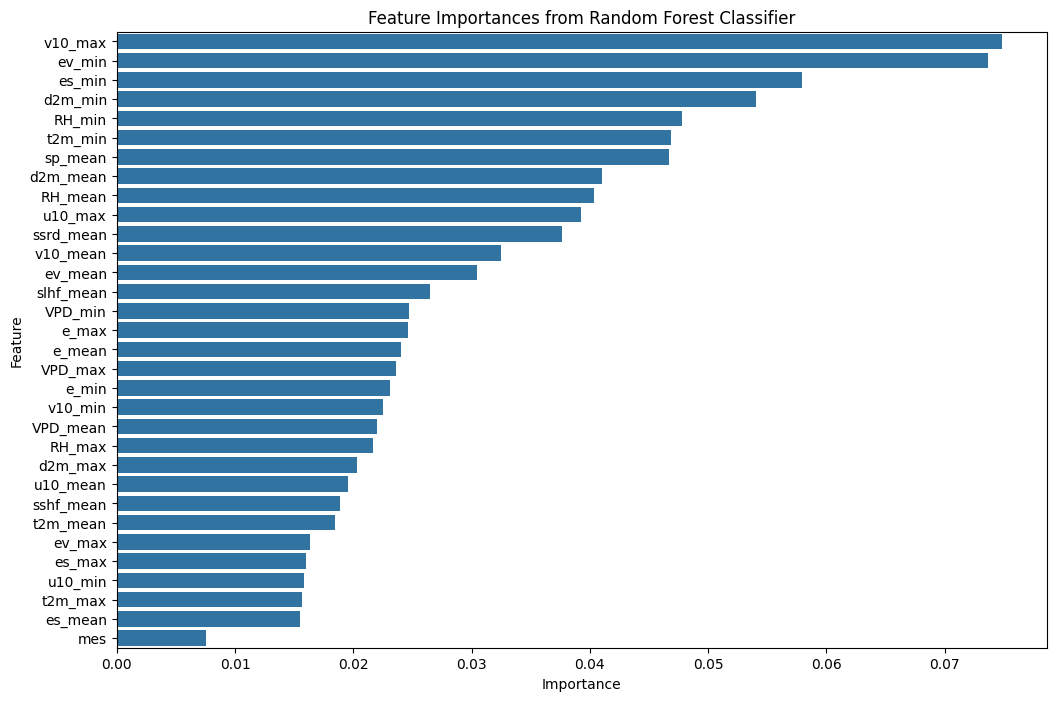

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
report(y_test, y_pred, feature_importance_df)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


33


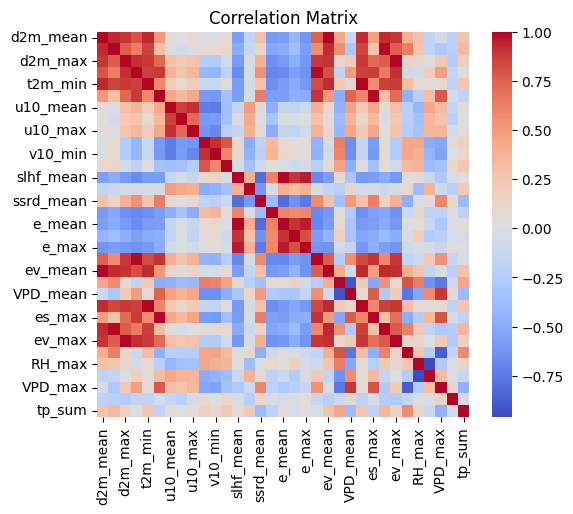

In [ ]:
df_diario1 = df_diario.drop(['data'], axis=1)
correlation_matrix = df_diario1.corr()
print(len(df_diario1.keys()))


# Create a heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

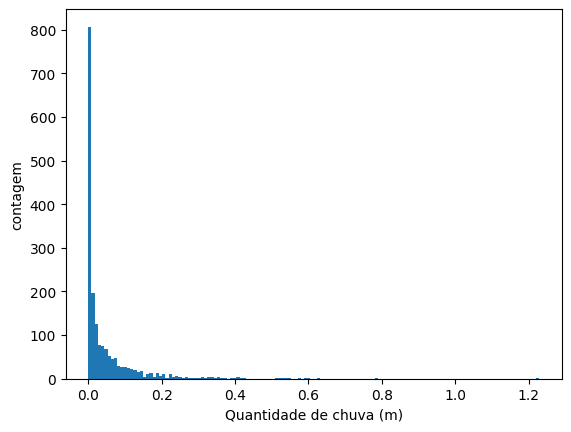

In [ ]:
plt.hist(df_diario['tp_sum'], 'auto')
plt.ylabel('contagem')
plt.xlabel('Quantidade de chuva (m)')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV 1/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.897 total time=   0.6s
[CV 2/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.890 total time=   0.6s
[CV 3/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.901 total time=   0.6s
[CV 4/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 4/5; 1/162] END max_depth=None, max

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=10)

In [ ]:
model = RandomForestClassifier(min_samples_leaf=4, n_estimators = 300, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nMatriz de confusão:\n", confusion_matrix(y_test, y_pred))
print("\nRelatório de classificação:\n", classification_report(y_test, y_pred))

Acurácia: 0.8493150684931506

Matriz de confusão:
 [[ 50  48]
 [  7 260]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.88      0.51      0.65        98
         1.0       0.84      0.97      0.90       267

    accuracy                           0.85       365
   macro avg       0.86      0.74      0.77       365
weighted avg       0.85      0.85      0.83       365



In [ ]:
def PCA_model(X, plotar=False, printar = False):
  pca = PCA()
  pca.fit(X)
  expl = pca.explained_variance_ratio_
  svalues = pca.singular_values_
  x = pca.transform(X)
  explainability = pca.explained_variance_ratio_.cumsum()
  factors = np.arange(1,X.shape[1]+1,1)
  if plotar:
    plt.scatter(factors,explainability)
    plt.hlines(0.9,0,20,'r')
    plt.xlabel('Número de componentes')
    plt.ylabel('Explicabilidade dos dados')
  p = factors[explainability<0.9].max()+1
  if p<2:
      p=2
  if printar:
    print('90% dos dados são explicados com as ' + str(p) + ' componentes.')
  pca = PCA(n_components=p)
  pca.fit(X)
  x = pca.transform(X)
  x = pd.DataFrame(x, columns=[f"PC{i+1}" for i in range(x.shape[1])])
  nomes_atributos = x.keys()
  return x, nomes_atributos


In [ ]:
from sklearn.decomposition import PCA
#x_pca, nomes =PCA_model(StandardScaler().fit_transform(df_diario.drop('data', axis=1)))
x_pca_train, nomes =PCA_model(StandardScaler().fit_transform(X_train_raw))
x_pca_test, nomes =PCA_model(StandardScaler().fit_transform(X_test_raw))

In [ ]:
model = RandomForestClassifier( random_state=42)
model.fit(x_pca_train, y_train)
y_pred = model.predict(x_pca_test)

Acurácia: 0.8246575342465754

Matriz de confusão:
 [[ 50  48]
 [ 16 251]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.76      0.51      0.61        98
         1.0       0.84      0.94      0.89       267

    accuracy                           0.82       365
   macro avg       0.80      0.73      0.75       365
weighted avg       0.82      0.82      0.81       365



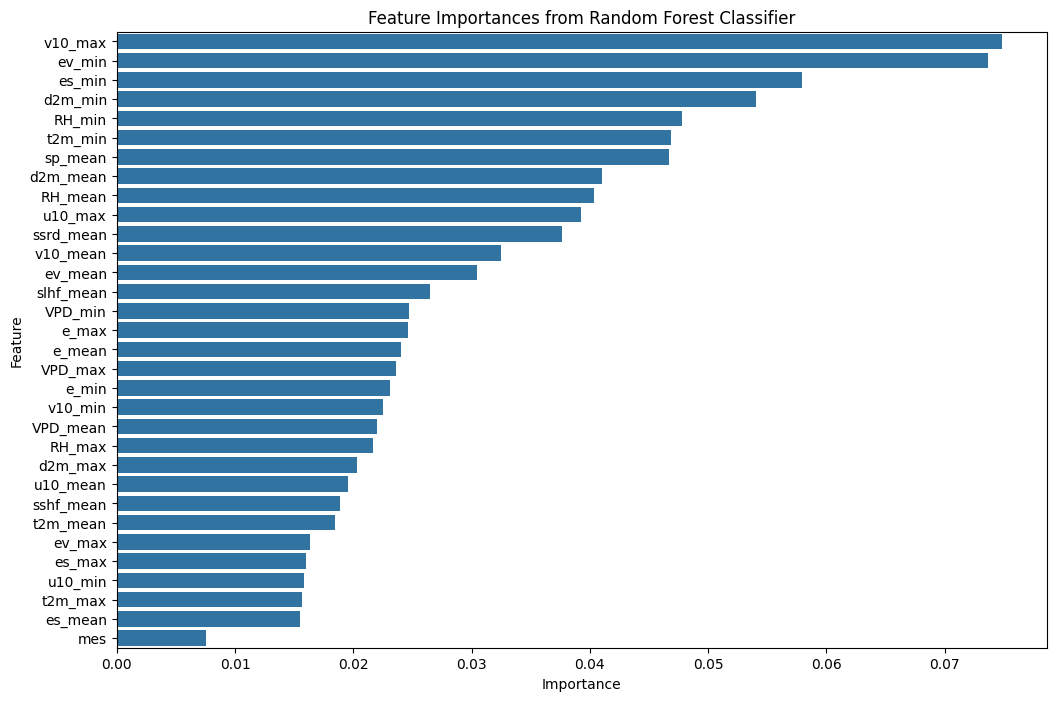

In [ ]:
report(y_test, y_pred, feature_importance_df)

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', verbose=10)
grid_search.fit(x_pca_train, y_train)

Fitting 5 folds for each of 162 candidates, totalling 810 fits
[CV 1/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 1/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.884 total time=   0.4s
[CV 2/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 2/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.890 total time=   0.3s
[CV 3/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 3/5; 1/162] END max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100;, score=0.894 total time=   0.3s
[CV 4/5; 1/162] START max_depth=None, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=100
[CV 4/5; 1/162] END max_depth=None, max

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42),
             param_grid={'max_depth': [None, 10, 20],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [100, 200, 300]},
             scoring='accuracy', verbose=10)

Acurácia: 0.8246575342465754

Matriz de confusão:
 [[ 49  49]
 [ 15 252]]

Relatório de classificação:
               precision    recall  f1-score   support

         0.0       0.77      0.50      0.60        98
         1.0       0.84      0.94      0.89       267

    accuracy                           0.82       365
   macro avg       0.80      0.72      0.75       365
weighted avg       0.82      0.82      0.81       365



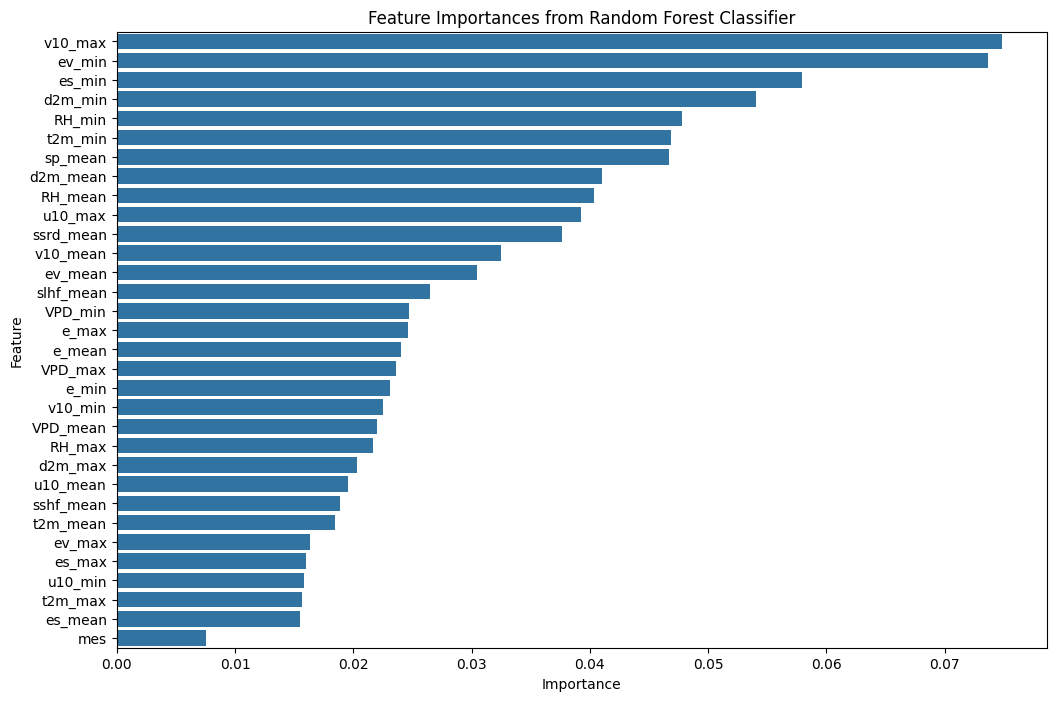

In [ ]:
model = RandomForestClassifier( min_samples_split=10, n_estimators=200, random_state=42)
model.fit(x_pca_train, y_train)
y_pred = model.predict(x_pca_test)

'''importances = model.feature_importances_
feature_names = X_train_raw.columns
feature_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)'''

report(y_test, y_pred, feature_importance_df)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA Model Fit Summary (on training data):
                               SARIMAX Results                                
Dep. Variable:                 tp_sum   No. Observations:                 1461
Model:                          ARIMA   Log Likelihood                1532.156
Date:                Tue, 18 Nov 2025   AIC                          -3060.312
Time:                        17:52:12   BIC                          -3049.739
Sample:                    01-01-2020   HQIC                         -3056.368
                         - 12-31-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0465      0.003     14.156      0.000       0.040       0.053
sigma2         0.0072   8.83e-05     81.406      0.000       0.007       0.007
Ljung-Bo

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Last date in data: 2024-12-31
Forecast date: 2025-01-01
Predicted Total Precipitation (tp_sum) on 2025-01-01: 0.0472


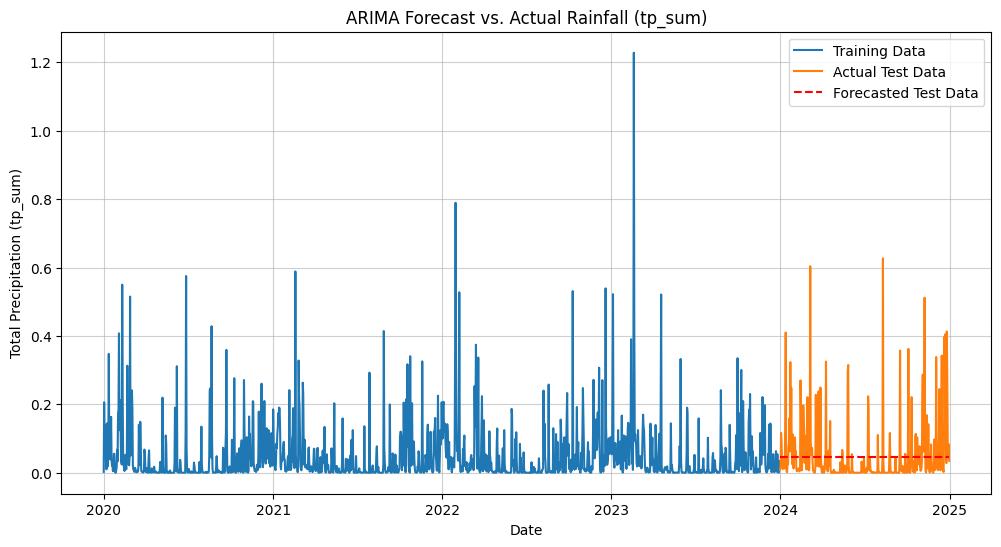

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = df_diario.copy()
df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')
df_ts = df['tp_sum']

split_idx = int(len(df_ts) * 0.8)
y_train = df_ts.iloc[:split_idx]
y_test = df_ts.iloc[split_idx:]

model_train = ARIMA(y_train)
model_fit = model_train.fit()
print(f"ARIMA Model Fit Summary (on training data):")
print(model_fit.summary())

y_pred = model_fit.forecast(steps=len(y_test))


mse = mean_squared_error(y_test, y_pred)
print(f"\nTest Mean Squared Error (MSE): {mse:.4f}")

final_model = ARIMA(df_ts)
final_model_fit = final_model.fit()

        # Forecast one step ahead (the day after the last date in the data)
next_day_forecast = final_model_fit.forecast(steps=1).iloc[0]
last_date = df_ts.index[-1].strftime('%Y-%m-%d')
next_date = (df_ts.index[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Last date in data: {last_date}")
print(f"Forecast date: {next_date}")
print(f"Predicted Total Precipitation (tp_sum) on {next_date}: {next_day_forecast:.4f}")

        # Interpretation based on common sense (rain is generally non-negative)
if next_day_forecast < 0:

  next_day_forecast = max(0.0, next_day_forecast)

plt.figure(figsize=(12, 6))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Test Data')
plt.plot(y_test.index, y_pred, label='Forecasted Test Data', color='red', linestyle='--')
plt.title(f'ARIMA Forecast vs. Actual Rainfall (tp_sum)')
plt.xlabel('Date')
plt.ylabel('Total Precipitation (tp_sum)')
plt.legend()
plt.grid(True, alpha=0.6)
plt.show()

In [ ]:
import pandas as pd
from statsmodels.formula.api import logit

df = df_diario.copy()
df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')
df['Rain_Today'] = (df['tp_sum'] > 0.0005).astype(int)
df['Rain_Yesterday'] = df['Rain_Today'].shift(1)
df_clean = df.dropna(subset=['Rain_Yesterday'])

# Define your split index for training
split_idx = int(len(df_clean) * 0.8)
train_data = df_clean.iloc[:split_idx]
test_data = df_clean.iloc[split_idx:]

# 2. Fit the Autoregressive Logistic Regression model
# This is the appropriate "ARIMA-like" model for binary prediction
logit_model = logit("Rain_Today ~ Rain_Yesterday", data=train_data).fit()
print("\n--- Correct Model for Binary Prediction (AR-Logit) ---")
print(logit_model.summary())

from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error, r2_score
)

y_prob = logit_model.predict(test_data)

y_pred = (y_prob >= 0.5).astype(int)

    # Extract actual values from the test set
y_actual = test_data['Rain_Today']



cm = confusion_matrix(y_actual, y_pred, labels=[0, 1])


accuracy = accuracy_score(y_actual, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm,
                     index=['Actual: No Rain (0)', 'Actual: Rain (1)'],
                     columns=['Predicted: No Rain (0)', 'Predicted: Rain (1)'])
print(cm_df)

print("\nClassification Report:")
print(classification_report(y_actual, y_pred, target_names=['No Rain', 'Rain'], labels=[0,1]))

tn = cm[0, 0] # True Negative: Correctly predicted No Rain
fp = cm[0, 1] # False Positive: Predicted Rain, but it was No Rain (Type I Error)
fn = cm[1, 0] # False Negative: Predicted No Rain, but it was Rain (Type II Error)
tp = cm[1, 1] # True Positive: Correctly predicted Rain

print("\nConfusion Matrix Interpretation:")
print(f"  True Negative (Correctly predicted NO RAIN): {tn} days")
print(f"  True Positive (Correctly predicted RAIN): {tp} days")
print(f"  False Positive (Missed Alarm - Predicted RAIN, Actual NO RAIN): {fp} days")
print(f"  False Negative (Missed Rain - Predicted NO RAIN, Actual RAIN): {fn} days")

Optimization terminated successfully.
         Current function value: 0.369470
         Iterations 6

--- Correct Model for Binary Prediction (AR-Logit) ---
                           Logit Regression Results                           
Dep. Variable:             Rain_Today   No. Observations:                 1460
Model:                          Logit   Df Residuals:                     1458
Method:                           MLE   Df Model:                            1
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.2217
Time:                        17:55:05   Log-Likelihood:                -539.43
converged:                       True   LL-Null:                       -693.06
Covariance Type:            nonrobust   LLR p-value:                 8.574e-69
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -0.3961      0.125     -3.

In [ ]:
print("--- 1. Data Loading and Preparation ---")
df = df_diario.copy()

df['data'] = pd.to_datetime(df['data'])
df = df.set_index('data')

df['Rain_Today'] = (df['tp_sum'] > 0.0005).astype(int)

predictors = ['t2m_mean', 'd2m_mean', 'sp_mean', 'u10_mean']

lag_columns = []
for col in predictors:
      lag_col_name = f'{col}_lag1'
      df[lag_col_name] = df[col].shift(1)
      lag_columns.append(lag_col_name)

df_clean = df.dropna(subset=lag_columns)

split_idx = int(len(df_clean) * 0.8)
train_data = df_clean.iloc[:split_idx]
test_data = df_clean.iloc[split_idx:]

formula = "Rain_Today ~ " + " + ".join(lag_columns)

print("\n--- 3. Model Fitting (Multivariable AR-Logit) ---")
print(f"Formula used: {formula}")

logit_model = logit(formula, data=train_data).fit(disp=0)
print("\nLogit Model Summary (on training data):")
print(logit_model.summary())


y_prob = logit_model.predict(test_data)

y_pred = (y_prob >= 0.5).astype(int)


y_actual = test_data['Rain_Today']


cm = confusion_matrix(y_actual, y_pred, labels=[0, 1])


accuracy = accuracy_score(y_actual, y_pred)

print(f"\nAccuracy: {accuracy:.4f}")

print("\nConfusion Matrix:")
cm_df = pd.DataFrame(cm,
                      index=['Actual: No Rain (0)', 'Actual: Rain (1)'],
                      columns=['Predicted: No Rain (0)', 'Predicted: Rain (1)'])
print(cm_df)

print("\nClassification Report:")


print(classification_report(y_actual, y_pred,
                            target_names=['No Rain', 'Rain'],
                            labels=[0, 1],
                            zero_division=0))

print("\n--- 5. Next Day Prediction ---")


final_logit_model = logit(formula, data=df_clean).fit(disp=0)


last_day_features = df.tail(1)[predictors].rename(columns=lambda x: f'{x}_lag1')


next_day_prob = final_logit_model.predict(last_day_features).iloc[0]
next_day_prediction = 'RAIN' if next_day_prob >= 0.5 else 'NO RAIN'

last_date = df.index[-1].strftime('%Y-%m-%d')
next_date = (df.index[-1] + pd.Timedelta(days=1)).strftime('%Y-%m-%d')

print(f"Weather conditions used (from {last_date}):")
print(last_day_features)
print(f"\nPredicted Probability of Rain on {next_date}: {next_day_prob:.4f}")
print(f"Final Prediction: {next_day_prediction}")

--- 1. Data Loading and Preparation ---

--- 3. Model Fitting (Multivariable AR-Logit) ---
Formula used: Rain_Today ~ t2m_mean_lag1 + d2m_mean_lag1 + sp_mean_lag1 + u10_mean_lag1

Logit Model Summary (on training data):
                           Logit Regression Results                           
Dep. Variable:             Rain_Today   No. Observations:                 1460
Model:                          Logit   Df Residuals:                     1455
Method:                           MLE   Df Model:                            4
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.3047
Time:                        18:03:54   Log-Likelihood:                -481.89
converged:                       True   LL-Null:                       -693.06
Covariance Type:            nonrobust   LLR p-value:                 4.135e-90
                    coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------